# Лабораторная работа №3. Визуализация данных
Для визуализации можно использовать любые библиотеки на свой выбор, но
обязательно продемонстрировать хотя бы 2 разных (например, matplotlib и seaborn).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Загрузите данные из файла «weather1.csv» о погоде в Перми. Загрузите только
следующие столбцы:
* a. Местное время в Перми
* b. T (температура воздуха в градусах Цельсия)
* c. P (атмосферное давление в мм.рт.ст.)
* d. U (относительная влажность в %)
* e. Ff (скорость ветра в м/с)
* f. N (облачность)
* g. H (высота основания облаков, м)
* h. VV (горизонтальная дальность видимости в км)

In [6]:
df = pd.read_csv('weather1.csv', sep=';', usecols=[
    'Местное время в Перми', 'T', 'P', 'U', 'Ff', 'N', 'H', 'VV'
])
df.head()

,Местное время в Перми,T,P,U,Ff,N,H,VV
0,31.12.2021 23:00,-9.8,762.5,83,3,100%.,600-1000,4.0
1,31.12.2021 20:00,-10.6,764.2,81,3,100%.,1000-1500,4.0
2,31.12.2021 17:00,-11.6,765.5,79,2,"90 или более, но не 100%",1000-1500,10.0
3,31.12.2021 14:00,-11.9,766.7,77,1,100%.,1000-1500,20.0
4,31.12.2021 11:00,-13.6,767.5,79,1,100%.,1000-1500,10.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Местное время в Перми  2919 non-null   object 
 1   T                      2919 non-null   float64
 2   P                      2917 non-null   float64
 3   U                      2919 non-null   int64  
 4   Ff                     2919 non-null   int64  
 5   N                      2916 non-null   object 
 6   H                      2551 non-null   object 
 7   VV                     2917 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 182.6+ KB


In [7]:
# Преобразуем время в datetime
df['Местное время в Перми'] = pd.to_datetime(df['Местное время в Перми'], dayfirst=True)

1. Постройте точечную диаграмму (диаграмму рассеяния) по признакам
температуры и относительной влажности.

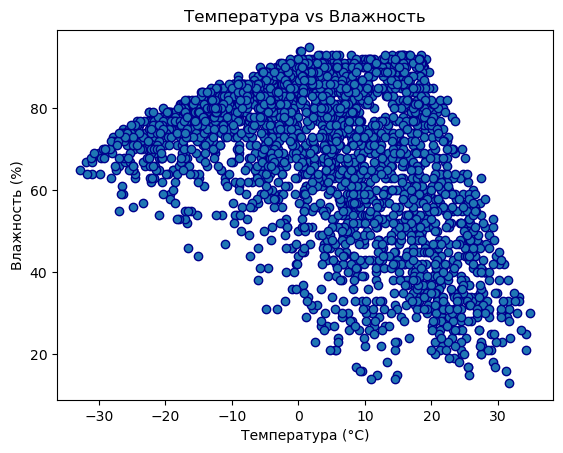

In [44]:
plt.scatter(df['T'], df['U'], edgecolor = "darkblue")
plt.xlabel('Температура (°C)')
plt.ylabel('Влажность (%)')
plt.title('Температура vs Влажность')
plt.show()

2. На построенной в предыдущем пункте диаграмме выделите точки
разными цветами в зависимости от облачности: синим – для которых облачность
составляет 100%; красным – все остальные. Сделайте полупрозрачными точки
того цвета, который рисуется на переднем плане (чтобы эти точки не полностью
закрывали точки другого цвета).

In [9]:
df.N.value_counts()

100%.                                                                 1427
Облаков нет.                                                           364
70 – 80%.                                                              285
20–30%.                                                                251
90  или более, но не 100%                                              222
40%.                                                                   111
60%.                                                                   106
50%.                                                                    83
10%  или менее, но не 0                                                 66
Небо не видно из-за тумана и/или других метеорологических явлений.       1
Name: N, dtype: int64

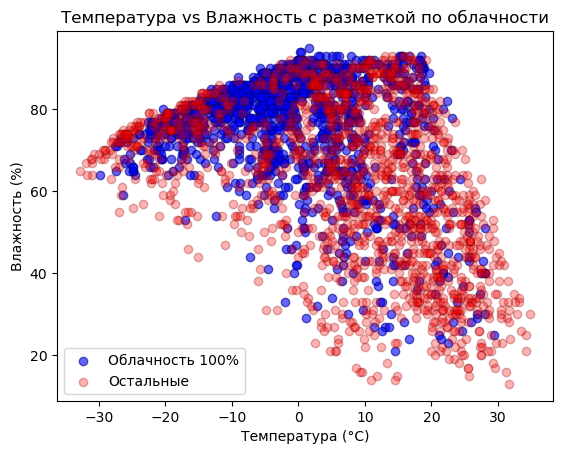

In [45]:
# Синие точки для облачности 100%
plt.scatter(df[df['N'] == "100%."]['T'], df[df['N'] == "100%."]['U'], 
            color='blue', edgecolor = "darkblue", alpha=0.6, label='Облачность 100%')
# Красные точки для остальных
plt.scatter(df[df['N'] != "100%."]['T'], df[df['N'] != "100%."]['U'], 
            color='red', edgecolor = "darkred", alpha=0.3, label='Остальные')
plt.xlabel('Температура (°C)')
plt.ylabel('Влажность (%)')
plt.legend()
plt.title('Температура vs Влажность с разметкой по облачности')
plt.show()

3. Постройте линейную диаграмму (график) изменения температуры в
зависимости от местного времени. Подписи на горизонтальной оси (времени)
должны быть различимы (подписывайте только дни или делайте подписи с
интервалом).

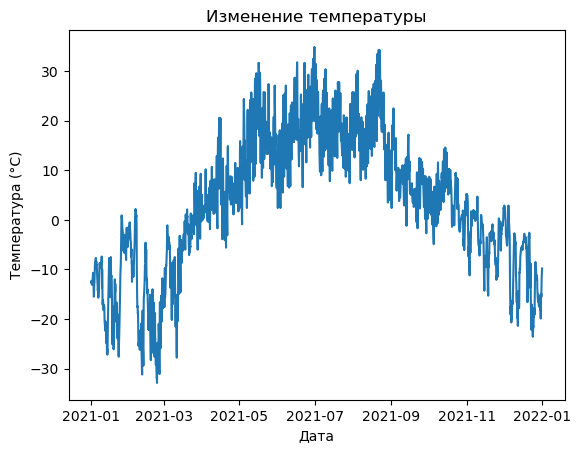

In [41]:
plt.plot(df['Местное время в Перми'], df['T'])
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.title('Изменение температуры')
plt.show()

4. Посчитайте по имеющимся данным среднемесячную температуру и
постройте столбчатую диаграмму (вертикальную) зависимости средней
температуры от месяца. Подсказка: создайте отдельный столбец с номером месяца
(вычислив его из столбца «Местное время»), а затем сгруппируйте данные по
этому столбцу

In [20]:
df['Месяц'] = df['Местное время в Перми'].dt.month
monthly_avg = df.groupby('Месяц')['T'].mean()
monthly_avg

Месяц
1    -12.958871
2    -17.419643
3     -5.660484
4      5.382500
5     16.275806
6     18.898333
7     18.444355
8     18.568145
9      7.556067
10     4.207258
11    -3.627500
12   -10.387500
Name: T, dtype: float64

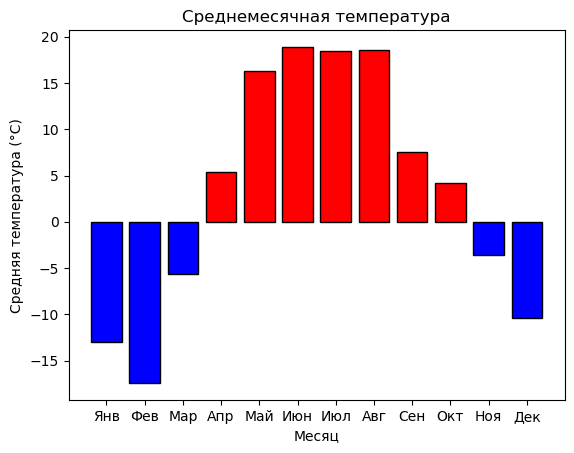

In [81]:
colors = ['blue' if val < 0 else 'red' for val in monthly_avg.values]
plt.bar(monthly_avg.index, monthly_avg.values, color=colors, edgecolor='black')
plt.xlabel('Месяц')
plt.ylabel('Средняя температура (°C)')
plt.title('Среднемесячная температура')

months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
plt.xticks(monthly_avg.index, [months[i-1] for i in monthly_avg.index])
plt.show()

5. Постройте ленточную диаграмму (горизонтальную), отразив на ней
количество имеющихся наблюдений для каждого варианта облачности

In [86]:
df['N'].value_counts()

100%.                                                                 1427
Облаков нет.                                                           364
70 – 80%.                                                              285
20–30%.                                                                251
90  или более, но не 100%                                              222
40%.                                                                   111
60%.                                                                   106
50%.                                                                    83
10%  или менее, но не 0                                                 66
Небо не видно из-за тумана и/или других метеорологических явлений.       1
Name: N, dtype: int64

In [84]:
short_N = df['N'].replace({
    'Небо не видно из-за тумана и/или других метеорологических явлений.': 'Небо не видно',
    '90  или более, но не 100%': '90%+ (но не 100%)',
    '10%  или менее, но не 0': '≤10% (но не 0)'
})

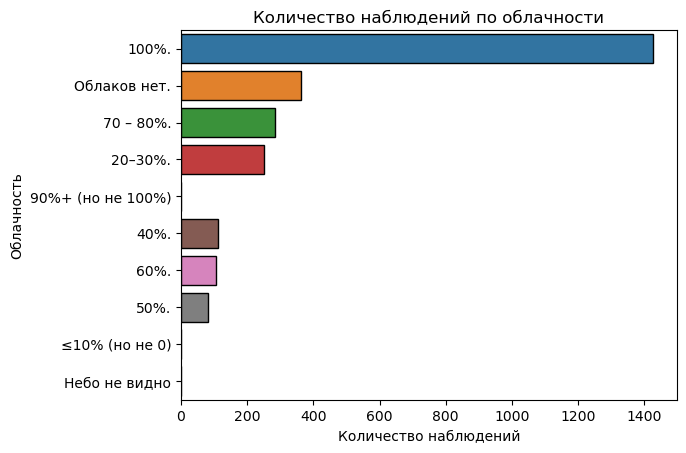

In [88]:
sns.countplot(y=df['N'], order=short_N.value_counts().index, edgecolor='black')
plt.xlabel('Количество наблюдений')
plt.ylabel('Облачность')
plt.title('Количество наблюдений по облачности')
plt.show()

6. Постройте гистограмму частот для температуры. На гистограмме
должно быть 10 диапазонов температуры.

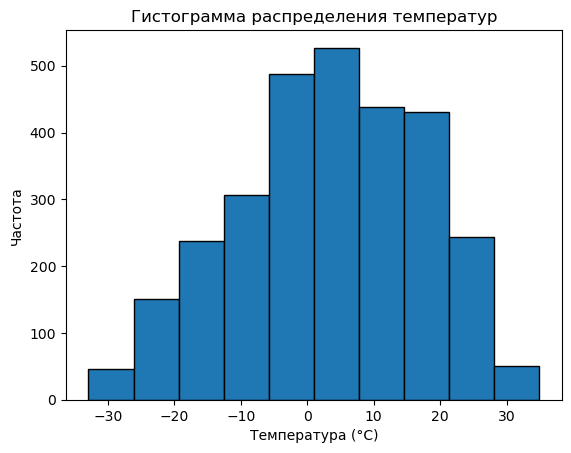

In [47]:
plt.hist(df['T'], bins=10, edgecolor='black')
plt.xlabel('Температура (°C)')
plt.ylabel('Частота')
plt.title('Гистограмма распределения температур')
plt.show()

7. Разбейте данные на 3 группы по значению горизонтальной дальности
видимости (одна группа – дальность видимости менее 5 км, вторая – от 5 до
15 км(включительно), третья – более 15 км). В одной области для каждой группы
постройте boxplot (диаграмму «ящик с усами») для признака «атмосферное
давление».

In [49]:
df.VV.value_counts()

20.00    1815
10.00     548
4.00      399
2.00      125
1.00       20
0.50        7
0.20        2
0.05        1
Name: VV, dtype: int64

In [52]:
def visibility_group(v):
    if v < 5:
        return 'Менее 5 км'
    elif 5 <= v <= 15:
        return '5-15 км'
    else:
        return 'Более 15 км'

df['Группа видимости'] = df['VV'].apply(visibility_group)
df['Группа видимости'].value_counts() 

Более 15 км    1817
Менее 5 км      554
5-15 км         548
Name: Группа видимости, dtype: int64

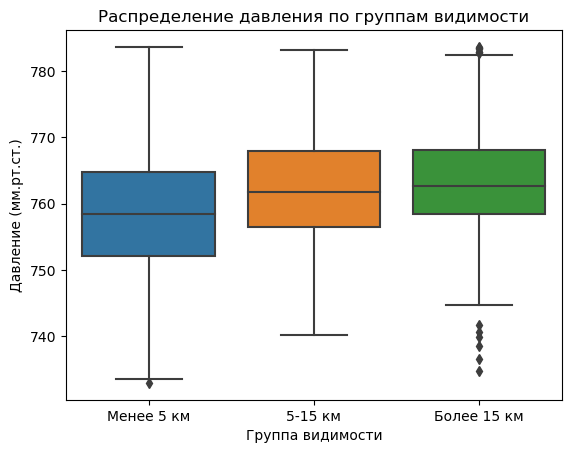

In [ ]:
sns.boxplot(x='Группа видимости', y='P', data=df)
plt.xlabel('Группа видимости')
plt.ylabel('Давление (мм.рт.ст.)')
plt.title('Распределение давления по группам видимости')
plt.show()
# в середине - медиана
# верхняя граница ящика - 75% квартиль
# нижняя граница ящика - 25% квартиль
# верхний усик = Q3 + 1.5 × высота_ящика, нижний усик = Q1 - 1.5 × высота_ящика


8. Постройте круговую диаграмму для признака «высота основания
облаков». Те группы, размер которых составляет менее 5%, объедините в одну
группу «Другое» (то есть такие группы не должны рисоваться как отдельные доли
на диаграмме, вместо них должна быть одна доля с названием «Другое»).

In [54]:
cloud_height_counts = df['H'].value_counts()
cloud_height_counts

600-1000                            778
1000-1500                           565
2000-2500                           516
2500 или более, или облаков нет.    347
300-600                             290
200-300                              43
100-200                              12
Name: H, dtype: int64

In [62]:
# Объединяем маленькие группы (менее 5%)
threshold = 0.05 * sum(cloud_height_counts)
threshold

127.55000000000001

In [ ]:
small_groups = cloud_height_counts[cloud_height_counts < threshold]
small_groups

200-300    43
100-200    12
Name: H, dtype: int64

In [65]:
other_count = small_groups.sum()
other_count

55

In [66]:
pie_data = cloud_height_counts[cloud_height_counts >= threshold]
pie_data['Другое'] = other_count
pie_data

600-1000                            778
1000-1500                           565
2000-2500                           516
2500 или более, или облаков нет.    347
300-600                             290
Другое                               55
Name: H, dtype: int64

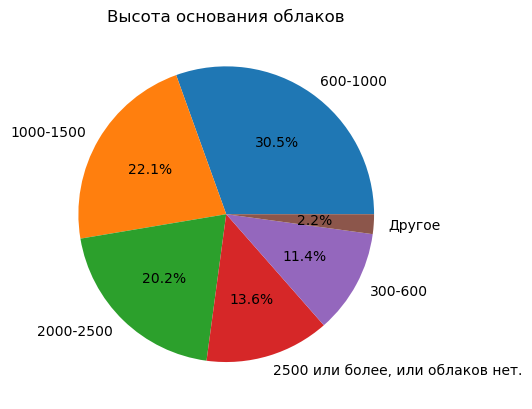

In [70]:
plt.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%')
plt.title('Высота основания облаков')
plt.show()

9. Постройте сводную таблицу (pivot_table), посчитав среднюю температуру
в зависимости от скорости ветра и облачности (то есть в сводной таблице
строками будут возможные значения скорости ветра(Ff), столбцами – возможные
варианты облачности(N), а значениями в таблице – средняя температура(T)). По
построенной таблице постройте тепловую карту (heatmap).

In [71]:
pivot_table = pd.pivot_table(df, 
                            values='T', 
                            index='Ff', 
                            columns='N', 
                            aggfunc='mean')
pivot_table

N,"10% или менее, но не 0",100%.,20–30%.,40%.,50%.,60%.,70 – 80%.,"90 или более, но не 100%",Небо не видно из-за тумана и/или других метеорологических явлений.,Облаков нет.
Ff,,,,,,,,,,
0,8.450000,0.668966,1.252174,3.366667,4.475000,8.700000,12.061538,11.166667,15.9,-2.140000
1,13.938889,1.659244,5.953030,6.644828,12.070370,11.176000,6.486441,8.497059,NaN,0.563636
2,10.550000,-1.389378,8.223529,8.072414,9.925000,8.627778,10.504082,10.478378,NaN,1.259375
3,11.436842,-1.777307,14.626087,10.132000,14.250000,9.955172,12.155405,11.944068,NaN,2.559259
4,5.150000,-2.125123,8.366667,19.169231,11.963636,19.200000,10.626471,9.382759,NaN,0.645455
5,20.000000,-0.696117,7.809091,4.266667,16.100000,-6.800000,3.300000,5.964286,NaN,0.388889
6,NaN,1.245833,-7.850000,NaN,NaN,NaN,24.100000,7.300000,NaN,NaN
7,NaN,-1.381818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,3.400000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


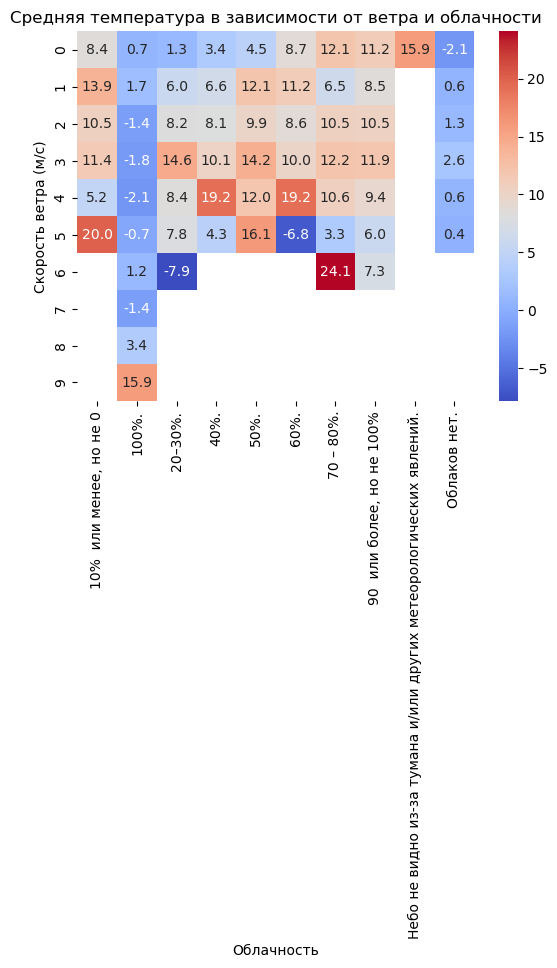

In [77]:
sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt='.1f')
plt.xlabel('Облачность')
plt.ylabel('Скорость ветра (м/с)')
plt.title('Средняя температура в зависимости от ветра и облачности')
plt.show()